<a href="https://colab.research.google.com/github/MarceloAndrade1999/Challenge-Telecom-X-2/blob/main/Challenge_Telecom_X_2.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [4]:
import pandas as pd
df = pd.read_csv("TelecomX_churn_procesado.csv")

print(df.shape)
display(df.head(3))
print(df.dtypes.head(12))



(7267, 21)


,customerID,Churn,customer_gender,customer_SeniorCitizen,customer_Partner,customer_Dependents,customer_tenure,phone_PhoneService,phone_MultipleLines,internet_InternetService,...,internet_OnlineBackup,internet_DeviceProtection,internet_TechSupport,internet_StreamingTV,internet_StreamingMovies,account_Contract,account_PaperlessBilling,account_PaymentMethod,account_Charges.Monthly,account_Charges.Total
0,0002-ORFBO,0,Female,0,1,1,9,1,0,DSL,...,1,0,1,1,0,One year,1,Mailed check,65.6,593.3
1,0003-MKNFE,0,Male,0,0,0,9,1,1,DSL,...,0,0,0,0,1,Month-to-month,0,Mailed check,59.9,542.4
2,0004-TLHLJ,1,Male,0,0,0,4,1,0,Fiber optic,...,0,1,0,0,0,Month-to-month,1,Electronic check,73.9,280.85


customerID                  object
Churn                        int64
customer_gender             object
customer_SeniorCitizen       int64
customer_Partner             int64
customer_Dependents          int64
customer_tenure              int64
phone_PhoneService           int64
phone_MultipleLines         object
internet_InternetService    object
internet_OnlineSecurity     object
internet_OnlineBackup       object
dtype: object


In [6]:

target_candidates = [c for c in df.columns if c.lower() in ['churn','churn_flag','abandono','se_fue']]
TARGET = target_candidates[0]

y = df[TARGET].astype(int)
X = df.drop(columns=[TARGET]).copy()


id_cols = [c for c in X.columns if 'id' in c.lower()]
if id_cols: X = X.drop(columns=id_cols)

for c in X.columns:
    as_num = pd.to_numeric(X[c], errors='coerce')
    if as_num.notna().mean() >= 0.90:
        X[c] = as_num.fillna(as_num.median())
    else:
        X[c] = X[c].astype(str).fillna('Desconocido')

num_cols = [c for c in X.columns if pd.api.types.is_numeric_dtype(X[c])]
cat_cols = [c for c in X.columns if c not in num_cols]

print("Cols num:", len(num_cols), "| Cols cat:", len(cat_cols))
print("Tasa de churn:", f"{y.mean():.2%}")


Cols num: 9 | Cols cat: 10
Tasa de churn: 25.72%


AUC LogisticRegression: 0.844
AUC RandomForest     : 0.817


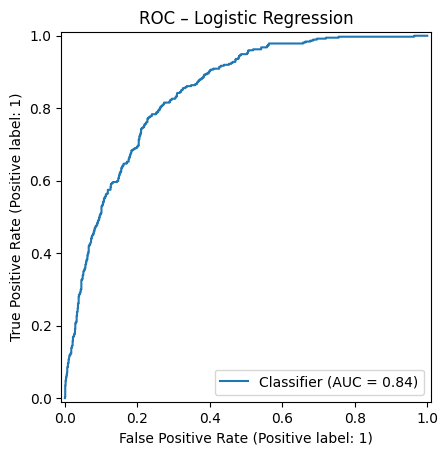

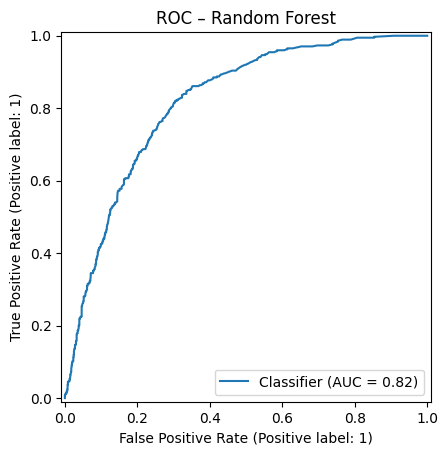

In [7]:
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import OneHotEncoder, StandardScaler
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import roc_auc_score, classification_report
import matplotlib.pyplot as plt
from sklearn.metrics import RocCurveDisplay

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, stratify=y, random_state=42
)

pre = ColumnTransformer([
    ('num', StandardScaler(with_mean=False), num_cols),
    ('cat', OneHotEncoder(handle_unknown='ignore', sparse_output=False), cat_cols)
])

logreg = Pipeline([
    ('pre', pre),
    ('clf', LogisticRegression(max_iter=400))
])

rf = Pipeline([
    ('pre', pre),
    ('clf', RandomForestClassifier(n_estimators=300, random_state=42))
])

logreg.fit(X_train, y_train)
rf.fit(X_train, y_train)

proba_lr = logreg.predict_proba(X_test)[:,1]
proba_rf = rf.predict_proba(X_test)[:,1]

auc_lr = roc_auc_score(y_test, proba_lr)
auc_rf = roc_auc_score(y_test, proba_rf)

print(f"AUC LogisticRegression: {auc_lr:.3f}")
print(f"AUC RandomForest     : {auc_rf:.3f}")

RocCurveDisplay.from_predictions(y_test, proba_lr)
plt.title("ROC – Logistic Regression")
plt.show()

RocCurveDisplay.from_predictions(y_test, proba_rf)
plt.title("ROC – Random Forest")
plt.show()


In [8]:
ohe = logreg.named_steps['pre'].named_transformers_['cat']
cat_feat_names = ohe.get_feature_names_out(cat_cols).tolist()
feat_names = num_cols + cat_feat_names


coefs = logreg.named_steps['clf'].coef_.ravel()
imp_lr = pd.Series(coefs, index=feat_names).sort_values(key=abs, ascending=False)


rf_feat_importances = rf.named_steps['clf'].feature_importances_
imp_rf = pd.Series(rf_feat_importances, index=feat_names).sort_values(ascending=False)

mejor_modelo = "RandomForest" if auc_rf >= auc_lr else "LogisticRegression"
auc_mejor = max(auc_lr, auc_rf)

print("📊 Conclusión – Proyecto Churn TelecomX")
print("---------------------------------------")
print(f"- Tasa global de churn: {y.mean():.2%}")
print(f"- Mejor modelo: {mejor_modelo} (AUC = {auc_mejor:.3f})")
print("\nTop 5 factores según LogReg (|coef|):")
print(imp_lr.head(5).to_string())
print("\nTop 5 factores según RandomForest (importancia):")
print(imp_rf.head(5).to_string())
print("\n✅ Recomendación:")
print("Enfocar retención en clientes con mayor propensión (contratos mensuales, tenure bajo,")
print("y combinaciones de servicio/pago de mayor riesgo). Ofrecer planes anuales/beneficios,")
print("mejorar onboarding de nuevos clientes y campañas específicas para segmentos críticos.")


📊 Conclusión – Proyecto Churn TelecomX
---------------------------------------
- Tasa global de churn: 25.72%
- Mejor modelo: LogisticRegression (AUC = 0.844)

Top 5 factores según LogReg (|coef|):
customer_tenure                   -1.412233
account_Contract_Two year         -0.694396
account_Charges.Total              0.664776
account_Contract_Month-to-month    0.572701
internet_InternetService_DSL      -0.379531

Top 5 factores según RandomForest (importancia):
account_Charges.Total              0.176134
account_Charges.Monthly            0.151691
customer_tenure                    0.145802
account_Contract_Month-to-month    0.058360
internet_OnlineSecurity_0          0.029502

✅ Recomendación:
Enfocar retención en clientes con mayor propensión (contratos mensuales, tenure bajo,
y combinaciones de servicio/pago de mayor riesgo). Ofrecer planes anuales/beneficios,
mejorar onboarding de nuevos clientes y campañas específicas para segmentos críticos.
